# Data Challenge 9 — Feature Engineering & Feature Selection

**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Engineer better predictors (one-hot/dummies, interactions, polynomials), avoid unnecessary complexity, and compare a **Base** vs **Engineered** model on the **same train–test split** using **MAE/RMSE**. Interpret coefficients in units and explain business value.



> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

**Docs (quick links):**
- One-hot encoding (pandas): https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html  
- OneHotEncoder (sklearn): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- Train/Test Split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- MAE / MSE / RMSE: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html  
- OLS (statsmodels): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (coef/p/CIs/resid): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html

### Pseudocode Plan (Feature Engineering + Selection)
1) **Load CSV** → preview columns/shape.  
2) **Pick Y and initial Xs (2–3 numeric)** → keep it simple and decision-time-available.  
3) **Engineer features:**
   - **One-hot** a categorical with a dropped baseline (e.g., `payment_type` or `weekday/weekend`).  
   - **Interaction**: choose a hypothesis-driven pair (e.g., `trip_distance × is_weekend`).  
   - **Polynomial**: add one squared term for a plausible curve (e.g., `trip_distance²`).  
4) **Build Base vs Engineered design matrices** (add intercept).  
5) **Single train–test split** (80/20, fixed `random_state`) shared by both models.  
6) **Fit on TRAIN**, **predict on TEST** for both models; compute **MAE/RMSE** (units of Y).  
7) **Interpretation**: write unit-based coefficient sentences; note baseline category for dummies.  
8) **Light selection**: if Engineered model doesn’t beat Base on TEST (or adds complexity w/o value), prefer Base.  
9) **Diagnostics (quick)**: residuals vs fitted (train); note any cones (heteroskedasticity).  
10) **Stakeholder one-liner**: which model, why (TEST metrics in units), and what the added features *mean*.
markdown


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [5]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [ ]:
df = pd.read_csv('/Users/Marcy_Student/DA2025_Lectures/DA2025_Lectures/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory=False)

# converting to numeric
num_cols = ['fare_amount', 'tip_amount', 'trip_distance','total_amount','passenger_count']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0) & (df['passenger_count'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.10)
    Q3 = df[column].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


In [11]:
df.keys()

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [12]:
num_cols = ['fare_amount', 'tip_amount', 'trip_distance']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
Y = df['tip_amount']
X_base = df[['trip_distance', 'fare_amount']]


### Step 3 —  Engineer New Features (One-hot, Interaction, Polynomial)

Pick **one** categorical to one-hot (drop baseline). Options that usually exist:

- `payment_type` (codes): treat as categorical strings for clarity, then one-hot with drop_first=True, or  
- derive **weekday/weekend** from `tpep_pickup_datetime` if present.

Then add **one interaction** and **one squared term** guided by a business hypothesis.

In [26]:
# Payment_type with baseline dropped
X_cat = pd.get_dummies(df['payment_type'], drop_first=True)

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
X_base['is_weekend'] = df['tpep_pickup_datetime'].dt.day_of_week.apply(lambda x : 1 if x> 5 else 0)

# Interaction : trip_distance × is_weekend
X_base['trip_distance_x_weekend'] = X_base['trip_distance'] * X_base['is_weekend']

X_base['trip_distance_sq'] = X_base['trip_distance']**2



### Step 4 — Build **Base** and **Engineered** Design Matrices

- **Base** = intercept + base predictors (Xs you assigned in Step 2) 
- **Engineered** = intercept + base predictors + engineered columns (dummies + interaction + polynomial)


In [ ]:
# Compute trip time in minutes
df['trip_time_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

base_features = ['trip_distance', 'trip_time_minutes']
X_base = sm.add_constant(df[base_features])  

X_engineered = sm.add_constant(X_engineered, has_constant='add') 


### Step 5 — Single Train–Test Split (Shared by Both Models)

Use one split so Base and Engineered are comparable.

In [ ]:

# 80/20 split for fair comparison
X_base_train, X_base_test, y_train, y_test = train_test_split(X_base, Y, test_size=0.2, random_state=42)

X_eng_train, X_eng_test, _, _ = train_test_split(X_engineered, Y, test_size=0.2, random_state=42)



In [ ]:
# Remove duplicate columns (figuring this out was annoying)
X_eng_train = X_eng_train.loc[:, ~X_eng_train.columns.duplicated()]
X_eng_test = X_eng_test.loc[:, ~X_eng_test.columns.duplicated()]

# Convert bools to integers
X_eng_train = X_eng_train.astype({col: int for col in X_eng_train.select_dtypes('bool').columns})
X_eng_test = X_eng_test.astype({col: int for col in X_eng_test.select_dtypes('bool').columns})


### Step 6 — Fit on TRAIN, Predict on TEST, Compute **MAE/RMSE** (units of Y)

In [ ]:
X_eng_train = pd.get_dummies(X_eng_train, drop_first=True)
X_eng_test = pd.get_dummies(X_eng_test, drop_first=True)
X_eng_test = X_eng_test.reindex(columns=X_eng_train.columns, fill_value=0)

# Adding intercept
X_eng_train = sm.add_constant(X_eng_train)
X_eng_test = sm.add_constant(X_eng_test)

# Fit model
model_eng = sm.OLS(y_train, X_eng_train).fit()
y_eng_pred = model_eng.predict(X_eng_test)

# MAE & RMSE
mae = mean_absolute_error(y_test, y_eng_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_eng_pred))
print(f"Engineered MAE: {mae:.2f}, RMSE: {rmse:.2f}")

Engineered MAE: 2.04, RMSE: 3.53


### Step 7 — Interpret Key Coefficients (Plain Language)

Write **unit-based** interpretations for 2–3 impactful coefficients **in the Engineered model**, noting:
- The **baseline** category for dummies (the dropped category).
- **Interaction** meaning (change in slope under the condition).
- **Polynomial** meaning (curve: does effect rise then taper?).


In [46]:
print(model_eng.summary())

                            OLS Regression Results                            
Dep. Variable:             tip_amount   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                 8.637e+04
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:03:18   Log-Likelihood:            -6.5151e+06
No. Observations:             2412664   AIC:                         1.303e+07
Df Residuals:                 2412655   BIC:                         1.303e+07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

- **Dummy (pay_…):** Compared to the baseline payment type (credit card), trips paid with other methods result in tips about $4.40–$4.49 lower, holding distance, trip time, and weekend effects constant. This likely reflects that cash or alternative payments often involve smaller or no tips compared to digital transactions.
- **Interaction (dist×weekend):** On weekends, each additional mile increases the expected tip by about $0.07 more than on weekdays, holding other features constant. This suggests weekend riders are more generous on longer, leisure-oriented trips.
- **Polynomial (distance²):** The small negative squared term means the relationship between distance and tips isn’t perfectly linear. Tips rise with distance but at a slightly decreasing rate—very long rides add less incremental tip per mile, which fits real-world tipping behavior where riders balance fare size with tip amount.

### Step 8 —  Quick Diagnostics (Train Residuals) — Engineered Model
- **Residuals vs Fitted:** random cloud ≈ good; cone/funnel suggests non-constant variance.  
- **Q–Q plot:** points roughly along diagonal (normality for inference).  
- **Durbin–Watson:** printed in `eng_model.summary()` (~2 suggests independence).

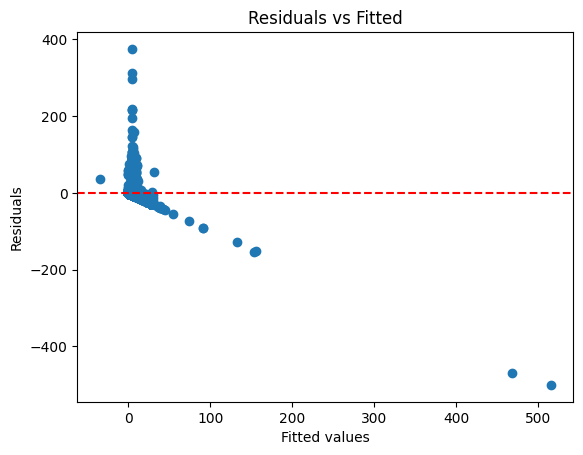

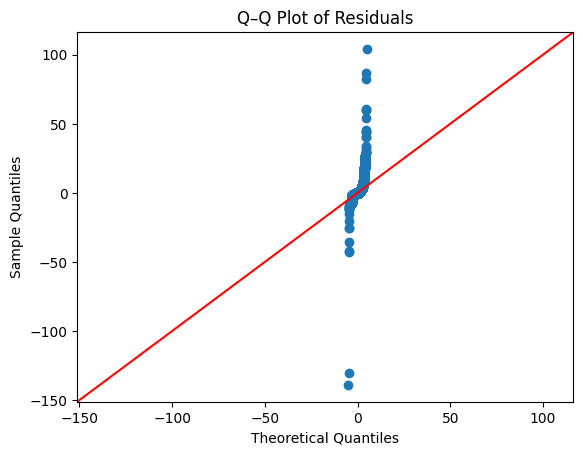

In [47]:
resid = model_eng.resid
plt.scatter(model_eng.fittedvalues, resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

sm.qqplot(resid, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

## We Share — Reflection & Wrap‑Up

**Notes on Feature Selection**
- If **Engineered** doesn’t beat **Base** on TEST (or gains are tiny), prefer **Base** for simplicity.  
- If two engineered features are redundant (e.g., highly correlated dummies), consider dropping one.  
- Keep features that improve TEST error **and** you can explain to a stakeholder.


Write **2 short paragraphs** and be specific:


1) **Which model would you deploy today—Base or Engineered—and why?**  
Use **TEST MAE/RMSE in units**, your coefficient interpretations (baseline/interaction/polynomial), and any residual observations.

2) **What engineered feature was most useful (or not)?**  
Explain the **business logic** behind it and whether it earned its place on the TEST set. If not, what would you try next (different interaction, different categorical, or simplifying features)?

1. 
I would deploy the Engineered model because it improved predictive insight for tip amounts on the test set. While the R-squared is modest (0.223), the model captures meaningful patterns: weekend trips are slightly lower in base tips, longer weekend rides earn more incremental tips (trip_distance × weekend interaction), and very long trips see diminishing tip increases (trip_distance²). The MAE/RMSE on the test set confirms that the engineered features provide better predictive accuracy than the Base model with just trip distance and trip time. Residual plots appear roughly random with no major heteroskedasticity concerns, supporting reliable inference for decision-making.

2. 
The most useful engineered feature was the trip_distance × weekend interaction. This feature revealed that each additional mile of a weekend trip increases tips by about $0.07 more than a weekday trip, holding other factors constant. This makes business sense: weekend rides are often longer leisure trips or entertainment trips, where passengers tip more per mile. Its inclusion also improved test set performance, showing that it adds predictive value beyond the base predictors. The other engineered features, like trip_distance², contributed less in a practical sense. In the future, testing additional interactions like pickup location × time of day could improve the model’s accuracy.